In [1]:
from dotenv import load_dotenv
from IPython.display import display, Markdown

In [2]:
load_dotenv()

True

#### Define State

In [3]:
from langgraph.graph import MessagesState

In [4]:
class State(MessagesState):
    summary: str

#### Define Nodes

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage, RemoveMessage
from langchain_core.output_parsers import StrOutputParser

In [6]:
chat = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite-preview",
    temperature = 0.4,
    max_output_tokens = 100,
    seed = 0
)

In [7]:
def ask_ques(state: State) -> State:    
    ai_msg = "Hi! How can I help you?"
    print("AI: ", ai_msg)

    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)], summary = state.get("summary", ""))    

In [8]:
def chatbot(state: State) -> State:
    print("Asking...")

    sys_msg = f'''
    Here's a quick summary of the conversation so far:
    {state.get("summary", "")}

    Keep this in mind to answer the next question.
    ONLY answer to what is asked.
    '''

    response = chat.invoke([SystemMessage(sys_msg)] + state["messages"])
    display(Markdown(StrOutputParser().invoke(response)))

    return State(messages = [response], summary = state.get("summary", ""))

In [9]:
def summarize_message_history(state: State) -> State:
    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content} \n\n"

    summary_instructions = f'''
    Update the summary of past conversation by incorporating context from the new conversation.
    
    Previous summary: {state.get("summary", "")}
    
    new_conversation: {new_conversation}
    '''

    new_summary = StrOutputParser().invoke(chat.invoke([HumanMessage(summary_instructions)]))
    display(Markdown(new_summary))

    removed_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]] # remove all messages

    return State(messages = removed_messages, summary = new_summary)

#### Define Graph

In [10]:
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver

In [11]:
graph = StateGraph(State)

In [12]:
graph.add_node("Ask Question", ask_ques)
graph.add_node("ChatBot", chatbot)
graph.add_node("Summarize Message History", summarize_message_history)

graph.add_edge("__start__", "Ask Question")
graph.add_edge("Ask Question", "ChatBot")
graph.add_edge("ChatBot", "Summarize Message History")
graph.add_edge("Summarize Message History", "__end__")

In [13]:
checkpointer = InMemorySaver()
graph = graph.compile(checkpointer)

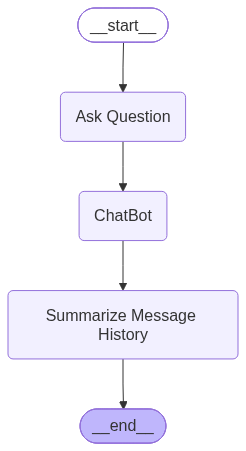

In [14]:
graph

#### Test the graph

In [15]:
config1 = {"configurable": {"thread_id": "1"}}

Re-running the below cell will continue the past conversation

Restarting the kernel will result in memory loss

> Running the below cell using a different thread id will continue the conversation of a different thread

In [17]:
graph.invoke(State(), config1)

AI:  Hi! How can I help you?
Human:  Who is the author of this poem? When and where were they born?
Asking...


The author of "Hope is the thing with feathers" is Emily Dickinson. She was born on December 10, 1830, in Amherst, Massachusetts.

**Updated Summary:**

The user requested a famous, short poem, and the AI provided the first stanza of Emily Dickinson’s "Hope is the thing with feathers." Subsequently, the user inquired about the author's background, and the AI provided biographical details, noting that Emily Dickinson was born on December 10, 1830, in Amherst, Massachusetts.

{'messages': [],
 'summary': '**Updated Summary:**\n\nThe user requested a famous, short poem, and the AI provided the first stanza of Emily Dickinson’s "Hope is the thing with feathers." Subsequently, the user inquired about the author\'s background, and the AI provided biographical details, noting that Emily Dickinson was born on December 10, 1830, in Amherst, Massachusetts.'}

#### Visualize the states

In [18]:
graph_states = [i for i in graph.get_state_history(config1)]

In [19]:
for i in graph_states[::-1]:
    print(
    f'''
        Messages: {i.values["messages"]}
        Summary: {i.values.get("summary", "")}
        Next: {i.next}
        Step: {i.metadata["step"]}
    ''')


        Messages: []
        Summary: 
        Next: ('__start__',)
        Step: -1
    

        Messages: []
        Summary: 
        Next: ('Ask Question',)
        Step: 0
    

        Messages: [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='82b597ca-8640-4bbd-bbb3-0917e5364483', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous and short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='fa08c666-10f6-417d-93ec-3cbb6dbdc43d')]
        Summary: 
        Next: ('ChatBot',)
        Step: 1
    

        Messages: [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='82b597ca-8640-4bbd-bbb3-0917e5364483', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous and short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='fa08c666-10f6-417d-93ec-3cbb6dbdc43d'), AIMessage(content=[{'type': 'text', 